# GPU Programming Essentials — A 15-Minute Tour
## Using 2D Convolution from Channel Estimation as an Example

**Platform:** Google Colab with T4 GPU  →  *Runtime → Change runtime type → T4 GPU*

---

### Why This Matters

In 5G/6G wireless systems, the receiver must **estimate the radio channel** at every resource element in a 2D OFDM grid (subcarriers × OFDM symbols). A CNN-based approach treats this grid as a **2D image** and uses convolution layers to interpolate/denoise. Each Conv2D layer slides a 3×3 filter over the grid — a perfect example to show **how GPUs parallelize work**.

```
Received signal:   Y[k, l]  =  H[k, l]  ×  X[k, l]  +  noise
Goal: Recover H[k,l] everywhere using a CNN → Conv2D is the core operation
```

**Today we focus on ONE thing:** How does a designer implement 2D convolution on a GPU, and how fast is it compared to a CPU?

We will cover:
1. **Threads, Blocks, Grid** — the 3-level CUDA hierarchy
2. **Writing a CUDA kernel** — the Conv2D example
3. **GPU memory allocation** — `mem_alloc`, `memcpy_htod`, `memcpy_dtoh`
4. **Timing** — computation time vs. memory transfer (the "memory wall")
5. **Scaling** — CPU vs GPU as problem size grows

---
## 1. CUDA Hierarchy: Threads → Blocks → Grid

A CUDA programmer must decide **how many threads** to launch and **how to organize** them.

### The 2D Mapping

Our 2D grid of resource elements maps directly to a 2D grid of CUDA threads:

```
OFDM cell (k, l)  →  one CUDA thread
─────────────────────────────────────────────────────────
k = blockIdx.y * blockDim.y + threadIdx.y   ← row (freq)
l = blockIdx.x * blockDim.x + threadIdx.x   ← col (time)
idx = k * N_SYM + l                         ← flat memory index
─────────────────────────────────────────────────────────
```

### The Designer's 3 Decisions

| Step | What | Example |
|------|------|---------|
| **1. Count threads** | Total threads = total work units | 32×16 = 512 cells → 512 threads |
| **2. Choose block size** | Group threads into blocks (typically 16×16) | 16×16 = 256 threads/block |
| **3. Compute grid** | grid = ceil(N / block_size) | ceil(16/16) × ceil(32/16) = 1×2 = 2 blocks |

The GPU hardware **automatically** schedules blocks onto SMs (Streaming Multiprocessors).

```
┌─────────────────────────────────────────────────────────────┐
│  PROGRAMMER DECIDES:  block size   (e.g. 16×16)            │
│  PROGRAMMER COMPUTES: grid size    = ceil(N / block_size)   │
│  GPU HARDWARE DECIDES: which SM runs which block            │
└─────────────────────────────────────────────────────────────┘
```

### Boundary Guard
Because `ceil()` may launch **more threads than data elements**, idle edge threads must be stopped:
```c
if (k < N_sc && l < N_sym)      // always include this!
    output[k * N_sym + l] = ...;
```

In [ ]:
!pip install pycuda --quiet

import pycuda.autoinit
import pycuda.driver as cuda
import numpy as np
import matplotlib.pyplot as plt
import math, time, warnings

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9})

def get_cores_per_sm(major, minor):
    """Accurate cores per SM by NVIDIA compute capability"""
    config = {
        (2,0): 32,  (2,1): 48,   # Fermi
        (3,0): 192, (3,2): 192, (3,5): 128, (3,7): 128,  # Kepler
        (5,0): 128, (5,2): 128, (5,3): 128,  # Maxwell
        (6,0): 64,  (6,1): 128, (6,2): 128,  # Pascal
        (7,0): 64,  (7,2): 64,  (7,5): 64,   # Volta/Turing
        (8,0): 64,  (8,6): 128, (8,9): 128,  # Ampere/Ada
        (9,0): 128, (10,0): 128 # Hopper/Blackwell
    }
    return config.get((major, minor), 64)  # Conservative default

dev = cuda.Device(0)
print('=' * 50)
print('  GPU INFORMATION')
print('=' * 50)

# Core GPU properties
sm_count = dev.get_attribute(cuda.device_attribute.MULTIPROCESSOR_COUNT)
max_threads_per_sm = dev.get_attribute(cuda.device_attribute.MAX_THREADS_PER_MULTIPROCESSOR)
max_threads_per_block = dev.get_attribute(cuda.device_attribute.MAX_THREADS_PER_BLOCK)
warp_size = dev.get_attribute(cuda.device_attribute.WARP_SIZE)

# Accurate cores calculation
major, minor = dev.compute_capability()
cores_per_sm = get_cores_per_sm(major, minor)
total_cuda_cores = sm_count * cores_per_sm
total_concurrent_threads = sm_count * max_threads_per_sm

# Additional useful metrics
max_blocks_per_sm = dev.get_attribute(cuda.device_attribute.MAX_BLOCKS_PER_MULTIPROCESSOR)
max_shared_mem_per_block = dev.get_attribute(cuda.device_attribute.MAX_SHARED_MEMORY_PER_BLOCK) / 1024**2  # MB
global_mem_gb = dev.total_memory() / 1e9

# Output
for k, v in [
    ('GPU name',              dev.name()),
    ('Compute capability',    f'{major}.{minor}'),
    ('Cores per SM',          cores_per_sm),
    ('Max threads / block',   max_threads_per_block),
    ('Max threads / SM',      max_threads_per_sm),
    ('Max blocks / SM',       max_blocks_per_sm),
    ('Warp size',             warp_size),
    ('Streaming multiprocs',  sm_count),
    ('Total CUDA cores',      total_cuda_cores),
    ('Total concurrent threads', total_concurrent_threads),
    ('Shared mem / block (MB)', f'{max_shared_mem_per_block:.1f}'),
    ('Global memory (GB)',    f'{global_mem_gb:.2f}'),
]:
    print(f'  {k:25s}: {v}')
print('=' * 50)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 73.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.8/98.8 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 11.7 MB/s eta 0:00:00
  GPU INFORMATION
  GPU name                 : Tesla T4
  Compute capability       : 7.5
  Cores per SM             : 64
  Max threads / block      : 1024
  Max threads / SM         : 1024
  Max blocks / SM          : 16
  Warp size                : 32
  Streaming multiprocs     : 40
  Total CUDA cores         : 2560
  Total concurrent threads : 40960
  Shared mem / block (MB)  : 0.0
  Global memory (GB)       : 15.64


In [ ]:
# ── CELL 2: Grid Constants + Launch Config Calculator ─────────────────────────

N_SC  = 32   # rows    — subcarriers  (frequency axis)
N_SYM = 16   # columns — OFDM symbols (time axis)

print(f'Lab grid : {N_SC} subcarriers × {N_SYM} OFDM symbols = {N_SC*N_SYM} cells')
print(f'Real 5G  : 1200 × 14 = {1200*14:,} cells\n')

def show_launch_config(N_sc, N_sym, block_size=16, label=''):
    bx = by = block_size
    gx = math.ceil(N_sym / bx)
    gy = math.ceil(N_sc  / by)
    total  = gx * gy * bx * by
    active = N_sc * N_sym
    idle   = total - active
    eff    = active / total * 100

    print(f"{'═'*55}")
    print(f"  {label or f'{N_sc} × {N_sym}'}")
    print(f"{'═'*55}")
    print(f"  Threads needed  : {N_sc}×{N_sym} = {active:,}")
    print(f"  Block (designer): {bx}×{by} = {bx*by} threads/block")
    print(f"  Grid (computed) : ceil({N_sym}/{bx})={gx} × ceil({N_sc}/{by})={gy} = {gx*gy} blocks")
    print(f"  Total launched  : {total:,}  |  Idle: {idle}  |  Efficiency: {eff:.0f}%")
    print(f"  PyCUDA: kernel(args, block=({bx},{by},1), grid=({gx},{gy},1))")
    print()

show_launch_config(N_SC, N_SYM, label=f'Lab grid — {N_SC}×{N_SYM}')
show_launch_config(1200, 14, label='Real 5G — 1200×14')

Lab grid : 32 subcarriers × 16 OFDM symbols = 512 cells
Real 5G  : 1200 × 14 = 16,800 cells

═══════════════════════════════════════════════════════
  Lab grid — 32×16
═══════════════════════════════════════════════════════
  Threads needed  : 32×16 = 512
  Block (designer): 16×16 = 256 threads/block
  Grid (computed) : ceil(16/16)=1 × ceil(32/16)=2 = 2 blocks
  Total launched  : 512  |  Idle: 0  |  Efficiency: 100%
  PyCUDA: kernel(args, block=(16,16,1), grid=(1,2,1))

═══════════════════════════════════════════════════════
  Real 5G — 1200×14
═══════════════════════════════════════════════════════
  Threads needed  : 1200×14 = 16,800
  Block (designer): 16×16 = 256 threads/block
  Grid (computed) : ceil(14/16)=1 × ceil(1200/16)=75 = 75 blocks
  Total launched  : 19,200  |  Idle: 2400  |  Efficiency: 88%
  PyCUDA: kernel(args, block=(16,16,1), grid=(1,75,1))



---
## 2. The Conv2D Kernel — CPU vs GPU

A 2D convolution slides a 3×3 filter over every cell in the grid.

**CPU version:** 4 nested loops (2 outer for position, 2 inner for the 3×3 patch) — sequential.

**GPU version:** The 2 outer loops become **thread indices** — each thread handles one output cell. The inner 3×3 loop runs inside every thread unchanged.

```
CPU:  for k ...          →  GPU:  k = blockIdx.y * blockDim.y + threadIdx.y
        for l ...        →        l = blockIdx.x * blockDim.x + threadIdx.x
          for dk ...     →          for dk ...   (unchanged)
            for dl ...   →            for dl ... (unchanged)
```

In [ ]:
# ── CELL 3: Conv2D — CPU + GPU Implementation ────────────────────────────────

import pycuda.driver as cuda
from pycuda.compiler import SourceModule

# ─── CPU: 4 nested loops, single-threaded ───────────────────────────────────
def conv2d_cpu(signal, kernel3x3):
    N_sc, N_sym = signal.shape
    out = np.zeros_like(signal)
    for k in range(N_sc):
        for l in range(N_sym):
            val = 0.0
            for dk in range(-1, 2):
                for dl in range(-1, 2):
                    r, c = k + dk, l + dl
                    if 0 <= r < N_sc and 0 <= c < N_sym:
                        val += signal[r, c] * kernel3x3[dk + 1, dl + 1]
            out[k, l] = val
    return out

# ─── GPU: CUDA C kernel — 2 outer loops replaced by thread indices ──────────
KERNEL_CONV2D = '''
__global__ void conv2d_pass(const float* input, const float* w,
                            float* output, int N_sc, int N_sym)
{
    int k = blockIdx.y * blockDim.y + threadIdx.y;
    int l = blockIdx.x * blockDim.x + threadIdx.x;

    if (k < N_sc && l < N_sym) {
        float val = 0.0f;
        for (int dk = -1; dk <= 1; dk++) {
            for (int dl = -1; dl <= 1; dl++) {
                int r = k + dk,  c = l + dl;
                float px = (r >= 0 && r < N_sc && c >= 0 && c < N_sym)
                            ? input[r * N_sym + c] : 0.0f;
                val += px * w[(dk + 1) * 3 + (dl + 1)];
            }
        }
        output[k * N_sym + l] = val;
    }
}
'''
mod = SourceModule(KERNEL_CONV2D)
conv2d_gpu_fn = mod.get_function('conv2d_pass')

print('CUDA kernel compiled successfully.')
print(f'Each thread processes one (k,l) cell and reads a 3×3 neighbourhood.')

CUDA kernel compiled successfully.
Each thread processes one (k,l) cell and reads a 3×3 neighbourhood.


---
## 3. GPU Memory Model — Allocation and Transfers

The GPU has its **own separate DRAM** (VRAM). Data must be explicitly moved:

| Step | API Call | Direction |
|------|----------|-----------|
| **Allocate** on GPU | `cuda.mem_alloc(nbytes)` | — |
| **Copy to GPU** | `cuda.memcpy_htod(gpu_buf, cpu_arr)` | CPU RAM → GPU DRAM |
| **Launch kernel** | `kernel_fn(args, block=..., grid=...)` | Runs on GPU |
| **Copy back** | `cuda.memcpy_dtoh(cpu_arr, gpu_buf)` | GPU DRAM → CPU RAM |

The **memory wall**: even if the kernel is fast, the PCIe transfers (H2D / D2H) add overhead. For small problems, this overhead can **dominate** and the GPU appears slower than the CPU.

CPU conv2d (kernel only) : 7.3709 ms  (4 nested loops)
GPU conv2d (kernel only) : 0.6509 ms  (2D threads)
Speedup                  : 11.3×
Max error (CPU vs GPU)   : 1.79e-07  ← numerically identical


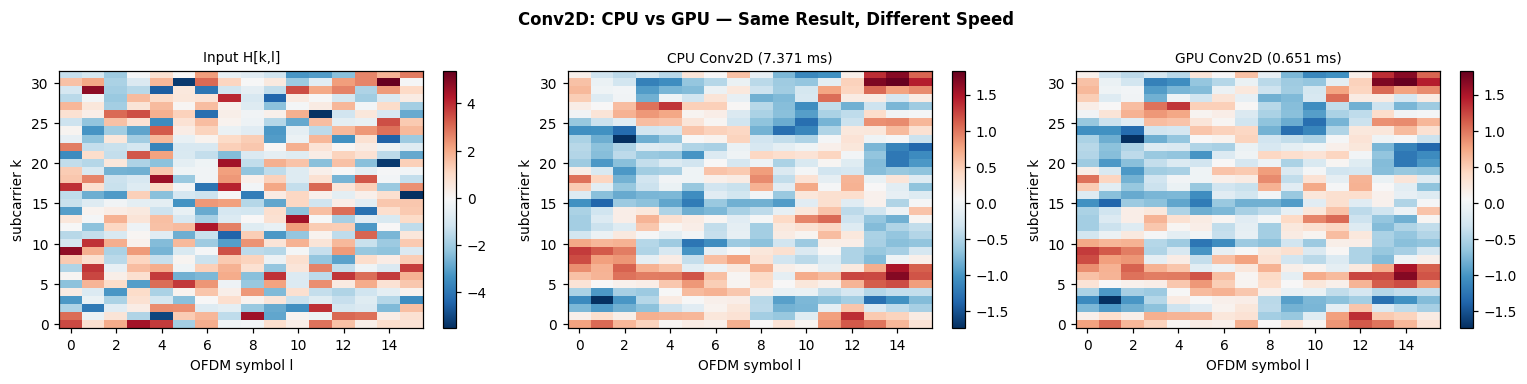

In [ ]:
# ── CELL 4: Run Conv2D on CPU and GPU, Compare Results ────────────────────────

smooth_w = np.ones((3, 3), dtype=np.float32) / 9.0
np.random.seed(0)
H_input = (np.random.randn(N_SC, N_SYM) * 2.0).astype(np.float32)

# ─── CPU timing ─────────────────────────────────────────────────────────────
t0 = time.perf_counter()
cpu_out = conv2d_cpu(H_input, smooth_w)
cpu_ms = (time.perf_counter() - t0) * 1000

# ─── GPU: allocate, transfer, launch, transfer back ─────────────────────────
# Step 1: Allocate buffers in GPU DRAM
w_gpu   = cuda.mem_alloc(smooth_w.nbytes)
in_gpu  = cuda.mem_alloc(H_input.nbytes)
out_gpu = cuda.mem_alloc(H_input.nbytes)

# Step 2: Copy inputs from CPU RAM → GPU DRAM (H2D)
cuda.memcpy_htod(w_gpu,  smooth_w.flatten())
cuda.memcpy_htod(in_gpu, H_input)

# Step 3: Launch config
BLK = 16
GX = math.ceil(N_SYM / BLK)
GY = math.ceil(N_SC  / BLK)

# Step 4: Time the kernel with CUDA events (GPU-side timers)
ev_s = cuda.Event(); ev_e = cuda.Event()
ev_s.record()
conv2d_gpu_fn(in_gpu, w_gpu, out_gpu,
              np.int32(N_SC), np.int32(N_SYM),
              block=(BLK, BLK, 1), grid=(GX, GY, 1))
ev_e.record(); ev_e.synchronize()
gpu_kernel_ms = ev_s.time_till(ev_e)

# Step 5: Copy result back GPU DRAM → CPU RAM (D2H)
gpu_out = np.empty_like(H_input)
cuda.memcpy_dtoh(gpu_out, out_gpu)

max_err = np.max(np.abs(cpu_out - gpu_out))

print(f'CPU conv2d (kernel only) : {cpu_ms:.4f} ms  (4 nested loops)')
print(f'GPU conv2d (kernel only) : {gpu_kernel_ms:.4f} ms  (2D threads)')
print(f'Speedup                  : {cpu_ms/gpu_kernel_ms:.1f}×')
print(f'Max error (CPU vs GPU)   : {max_err:.2e}  ← numerically identical')

# ── Visualization ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, data, title in zip(axes,
        [H_input, cpu_out, gpu_out],
        ['Input H[k,l]',
         f'CPU Conv2D ({cpu_ms:.3f} ms)',
         f'GPU Conv2D ({gpu_kernel_ms:.3f} ms)']):
    im = ax.imshow(data, aspect='auto', cmap='RdBu_r', origin='lower')
    ax.set_xlabel('OFDM symbol l'); ax.set_ylabel('subcarrier k')
    ax.set_title(title, fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle('Conv2D: CPU vs GPU — Same Result, Different Speed', fontweight='bold')
plt.tight_layout(); plt.show()

---
## 4. The Memory Wall — Compute Time vs Transfer Overhead

The **true cost** of a GPU call = H2D transfer + kernel execution + D2H transfer.

For small problems, the PCIe data transfer time **dominates** kernel execution time.
This is the **memory wall** — the real bottleneck is moving data, not computing.

The cell below measures each component separately using CUDA Events.

Grid: 32×16 = 512 cells  |  Averaged over 50 runs
───────────────────────────────────────────────────────
  H2D transfer (CPU→GPU) : 0.0196 ms  ( 34.9%)
  Kernel execution       : 0.0211 ms  ( 37.7%)
  D2H transfer (GPU→CPU) : 0.0154 ms  ( 27.4%)
  ─────────────────────────────────
  Total GPU (end-to-end) : 0.0562 ms
  CPU conv2d             : 7.3709 ms

  ✓  GPU is faster even with transfer overhead.


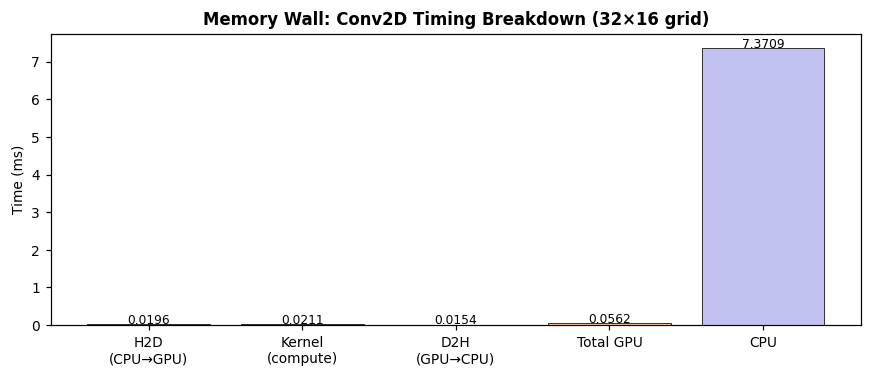

In [ ]:
# ── CELL 5: Memory Wall — Measuring Transfer vs Compute ──────────────────────

N_REPS = 50

# Prepare data
np.random.seed(42)
H_mw = (np.random.randn(N_SC, N_SYM) * 2.0).astype(np.float32)
w_mw = np.ones((3, 3), dtype=np.float32) / 9.0

# Allocate GPU buffers
w_g   = cuda.mem_alloc(w_mw.nbytes)
in_g  = cuda.mem_alloc(H_mw.nbytes)
out_g = cuda.mem_alloc(H_mw.nbytes)

# Warm-up run
cuda.memcpy_htod(w_g, w_mw.flatten())
cuda.memcpy_htod(in_g, H_mw)
conv2d_gpu_fn(in_g, w_g, out_g, np.int32(N_SC), np.int32(N_SYM),
              block=(BLK, BLK, 1), grid=(GX, GY, 1))
cuda.Context.synchronize()

# ── Measure H2D transfer time ────────────────────────────────────────────────
ev1 = cuda.Event(); ev2 = cuda.Event()
ev1.record()
for _ in range(N_REPS):
    cuda.memcpy_htod(in_g, H_mw)
    cuda.memcpy_htod(w_g, w_mw.flatten())
ev2.record(); ev2.synchronize()
h2d_ms = ev1.time_till(ev2) / N_REPS

# ── Measure kernel-only time ─────────────────────────────────────────────────
ev3 = cuda.Event(); ev4 = cuda.Event()
ev3.record()
for _ in range(N_REPS):
    conv2d_gpu_fn(in_g, w_g, out_g, np.int32(N_SC), np.int32(N_SYM),
                  block=(BLK, BLK, 1), grid=(GX, GY, 1))
ev4.record(); ev4.synchronize()
kernel_ms = ev3.time_till(ev4) / N_REPS

# ── Measure D2H transfer time ────────────────────────────────────────────────
result_tmp = np.empty_like(H_mw)
ev5 = cuda.Event(); ev6 = cuda.Event()
ev5.record()
for _ in range(N_REPS):
    cuda.memcpy_dtoh(result_tmp, out_g)
ev6.record(); ev6.synchronize()
d2h_ms = ev5.time_till(ev6) / N_REPS

total_gpu_ms = h2d_ms + kernel_ms + d2h_ms

print(f'Grid: {N_SC}×{N_SYM} = {N_SC*N_SYM} cells  |  Averaged over {N_REPS} runs')
print(f'─' * 55)
print(f'  H2D transfer (CPU→GPU) : {h2d_ms:.4f} ms  ({h2d_ms/total_gpu_ms*100:5.1f}%)')
print(f'  Kernel execution       : {kernel_ms:.4f} ms  ({kernel_ms/total_gpu_ms*100:5.1f}%)')
print(f'  D2H transfer (GPU→CPU) : {d2h_ms:.4f} ms  ({d2h_ms/total_gpu_ms*100:5.1f}%)')
print(f'  ─────────────────────────────────')
print(f'  Total GPU (end-to-end) : {total_gpu_ms:.4f} ms')
print(f'  CPU conv2d             : {cpu_ms:.4f} ms')
print()
if total_gpu_ms > cpu_ms:
    print(f'  ⚠  For this SMALL grid, GPU is SLOWER end-to-end due to transfer overhead!')
    print(f'     This is the "memory wall" — the PCIe bus is the bottleneck.')
else:
    print(f'  ✓  GPU is faster even with transfer overhead.')

# ── Bar chart ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3.5))
components = ['H2D\n(CPU→GPU)', 'Kernel\n(compute)', 'D2H\n(GPU→CPU)', 'Total GPU', 'CPU']
times      = [h2d_ms, kernel_ms, d2h_ms, total_gpu_ms, cpu_ms]
colors     = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0']
bars = ax.bar(components, times, color=colors, edgecolor='black', linewidth=0.5)
for b, t in zip(bars, times):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
            f'{t:.4f}', ha='center', fontsize=8)
ax.set_ylabel('Time (ms)')
ax.set_title(f'Memory Wall: Conv2D Timing Breakdown ({N_SC}×{N_SYM} grid)', fontweight='bold')
plt.tight_layout(); plt.show()

---
## 5. Scaling — When Does the GPU Win?

As the grid grows (toward real 5G sizes: 1200 subcarriers × 14 symbols), the GPU's massively parallel execution **dominates** the fixed transfer overhead.

The cell below sweeps `N_SC` from 32 → 2048 and plots:
- **CPU time** (single-threaded 4-loop convolution)
- **GPU kernel-only time** (just the computation)
- **GPU end-to-end time** (H2D + kernel + D2H)

N_SC=   32  |  CPU:    2.033 ms  |  GPU kernel:   0.0107 ms  |  GPU e2e:    0.039 ms  |  Speedup (kernel):   190.2×  (e2e):   52.1×
N_SC=   64  |  CPU:    3.895 ms  |  GPU kernel:   0.0121 ms  |  GPU e2e:    0.037 ms  |  Speedup (kernel):   322.3×  (e2e):  104.6×
N_SC=  128  |  CPU:    8.743 ms  |  GPU kernel:   0.0106 ms  |  GPU e2e:    0.040 ms  |  Speedup (kernel):   821.9×  (e2e):  216.0×
N_SC=  256  |  CPU:   15.990 ms  |  GPU kernel:   0.0102 ms  |  GPU e2e:    0.045 ms  |  Speedup (kernel):  1573.6×  (e2e):  357.0×
N_SC=  512  |  CPU:   49.982 ms  |  GPU kernel:   0.0162 ms  |  GPU e2e:    0.067 ms  |  Speedup (kernel):  3092.0×  (e2e):  749.1×
N_SC= 1024  |  CPU:  103.847 ms  |  GPU kernel:   0.0103 ms  |  GPU e2e:    0.072 ms  |  Speedup (kernel): 10097.1×  (e2e): 1445.1×
N_SC= 1200  |  CPU:   74.609 ms  |  GPU kernel:   0.0106 ms  |  GPU e2e:    0.080 ms  |  Speedup (kernel):  7035.4×  (e2e):  938.1×
N_SC= 2048  |  CPU:  130.190 ms  |  GPU kernel:   0.0106 ms  |  GPU e2e:    

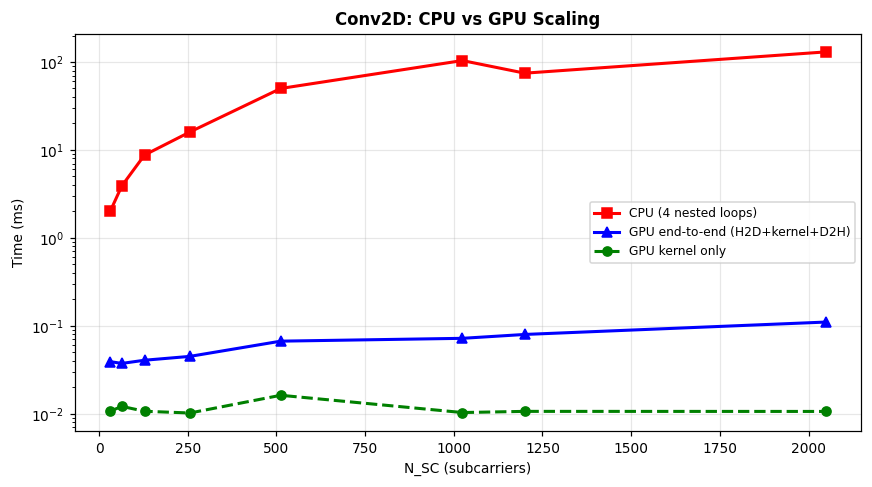

In [ ]:
import matplotlib.pyplot as plt

# ── CELL 6: Scaling Experiment — CPU vs GPU ──────────────────────────────────

N_SYM_SCALE = 14
sc_sizes = [32, 64, 128, 256, 512, 1024, 1200, 2048]
N_REPS_S = 20

cpu_times  = []
gpu_kernel_times = []
gpu_e2e_times = []

for N in sc_sizes:
    sig = (np.random.randn(N, N_SYM_SCALE) * 2.0).astype(np.float32)

    # ── CPU ──────────────────────────────────────────────────────────────────
    t0 = time.perf_counter()
    for _ in range(N_REPS_S):
        conv2d_cpu(sig, smooth_w)
    cpu_times.append((time.perf_counter() - t0) * 1000 / N_REPS_S)

    # ── GPU setup ────────────────────────────────────────────────────────────
    sg = cuda.mem_alloc(sig.nbytes)
    wg = cuda.mem_alloc(smooth_w.nbytes)
    og = cuda.mem_alloc(sig.nbytes)
    GX_s = math.ceil(N_SYM_SCALE / BLK)
    GY_s = math.ceil(N / BLK)

    # Warm-up
    cuda.memcpy_htod(sg, sig); cuda.memcpy_htod(wg, smooth_w.flatten())
    conv2d_gpu_fn(sg, wg, og, np.int32(N), np.int32(N_SYM_SCALE),
                  block=(BLK, BLK, 1), grid=(GX_s, GY_s, 1))
    cuda.Context.synchronize()

    # GPU kernel-only timing
    ev_a = cuda.Event(); ev_b = cuda.Event()
    ev_a.record()
    for _ in range(N_REPS_S):
        conv2d_gpu_fn(sg, wg, og, np.int32(N), np.int32(N_SYM_SCALE),
                      block=(BLK, BLK, 1), grid=(GX_s, GY_s, 1))
    ev_b.record(); ev_b.synchronize()
    gpu_kernel_times.append(ev_a.time_till(ev_b) / N_REPS_S)

    # GPU end-to-end timing (H2D + kernel + D2H)
    tmp = np.empty_like(sig)
    ev_c = cuda.Event(); ev_d = cuda.Event()
    ev_c.record()
    for _ in range(N_REPS_S):
        cuda.memcpy_htod(sg, sig)
        cuda.memcpy_htod(wg, smooth_w.flatten())
        conv2d_gpu_fn(sg, wg, og, np.int32(N), np.int32(N_SYM_SCALE),
                      block=(BLK, BLK, 1), grid=(GX_s, GY_s, 1))
        cuda.memcpy_dtoh(tmp, og)
    ev_d.record(); ev_d.synchronize()
    gpu_e2e_times.append(ev_c.time_till(ev_d) / N_REPS_S)

    print(f'N_SC={N:>5}  |  CPU: {cpu_times[-1]:8.3f} ms  ' # Removed the f-string for better readability
          f'|  GPU kernel: {gpu_kernel_times[-1]:8.4f} ms  ' # Removed the f-string for better readability
          f'|  GPU e2e: {gpu_e2e_times[-1]:8.3f} ms  ' # Removed the f-string for better readability
          f'|  Speedup (kernel): {cpu_times[-1]/gpu_kernel_times[-1]:>7.1f}×'
          f'  (e2e): {cpu_times[-1]/gpu_e2e_times[-1]:>6.1f}×')

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(1, 1, figsize=(8, 4.5)) # Changed to 1,1 for single plot

ax1.plot(sc_sizes, cpu_times, 'rs-', label='CPU (4 nested loops)', linewidth=2)
ax1.plot(sc_sizes, gpu_e2e_times, 'b^-', label='GPU end-to-end (H2D+kernel+D2H)', linewidth=2)
ax1.plot(sc_sizes, gpu_kernel_times, 'go--', label='GPU kernel only', linewidth=2)
ax1.set_xlabel('N_SC (subcarriers)'); ax1.set_ylabel('Time (ms)')
ax1.set_title('Conv2D: CPU vs GPU Scaling', fontweight='bold')
ax1.legend(fontsize=8); ax1.set_yscale('log'); ax1.grid(True, alpha=0.3)

# Removed code for the second plot (speedup plot)

plt.tight_layout(); plt.show()


---
## Key Takeaways

| Concept | What You Saw |
|---------|-------------|
| **Thread = 1 work unit** | Each thread computes one output cell of the convolution |
| **Block = group of threads** | 16×16 = 256 threads share an SM; chosen by the designer |
| **Grid = collection of blocks** | Computed via `ceil(N / block_size)` to cover the full problem |
| **Boundary guard** | `if (k < N_sc && l < N_sym)` prevents out-of-bounds writes |
| **GPU memory lifecycle** | `mem_alloc` → `memcpy_htod` → kernel launch → `memcpy_dtoh` |
| **Memory wall** | For small grids, PCIe transfer time dominates — GPU appears slower |
| **Scaling** | As problem grows (real 5G: 1200×14), GPU speedup becomes massive |

In a real CNN channel estimator, the data stays on the GPU between layers — only the final result crosses the PCIe bus back to the CPU. This eliminates the memory wall for intermediate layers.